In [5]:
import zipfile
from pathlib import Path

zip_path = Path("archive (16).zip")      # zip file in current folder
extract_to = Path(".")                  # extract into current folder

with zipfile.ZipFile(zip_path, "r") as zf:
    zf.extractall(extract_to)

print(f"Extracted '{zip_path}' to '{extract_to.resolve()}'")

Extracted 'archive (16).zip' to 'C:\Users\dell\.cursor\projects\AlexNet+svm'


In [41]:
import os
import random
import json
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from tqdm import tqdm
from PIL import Image
from collections import Counter

import torch
import torch.nn as nn
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, f1_score, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, auc
)
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import GridSearchCV

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")


SEED = 42
random.seed(SEED)
np.random.seed(SEED)

sns.set_theme(palette='muted')
print('Imports done.')

Using device: cpu
Imports done.


In [8]:
data_dir = Path(r"C:\Users\dell\.cursor\projects\AlexNet+svm\combined_images")

IMAGE_SIZE  = 224
USE_RATIO   = 1.0
TRAIN_RATIO = 0.80
VAL_RATIO   = 0.10

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

CLASS_NAMES = sorted(os.listdir(data_dir))
NUM_CLASSES = len(CLASS_NAMES)
# Friendly short names for plots
SHORT_NAMES = [c.replace('Demented', '').replace('Non', 'Non-D') for c in CLASS_NAMES]
print(f'Classes ({NUM_CLASSES}): {CLASS_NAMES}')

Classes (4): ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']


Total images: 44000


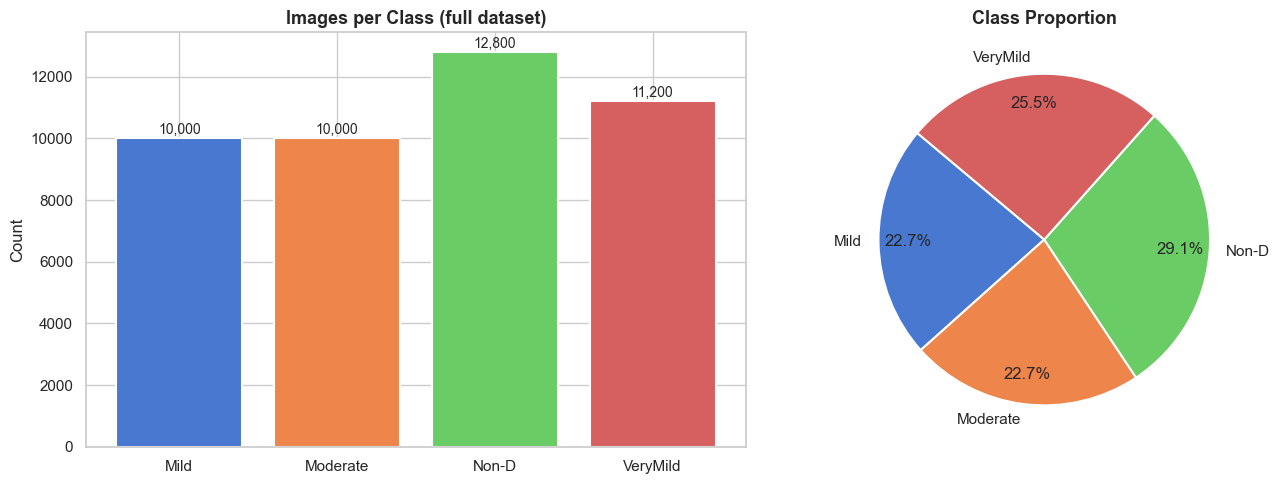

In [10]:
all_paths  = []
all_labels = []
class_sizes = {}

for idx, cls in enumerate(CLASS_NAMES):
    cls_dir = os.path.join(data_dir, cls)
    files   = [f for f in os.listdir(cls_dir)
               if os.path.isfile(os.path.join(cls_dir, f))]
    random.shuffle(files)
    n = int(len(files) * USE_RATIO)
    class_sizes[cls] = n
    for fname in files[:n]:
        all_paths.append(os.path.join(cls_dir, fname))
        all_labels.append(idx)

print(f"Total images: {len(all_paths)}")

# ── Bar chart of class sizes ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = sns.color_palette('muted', NUM_CLASSES)
bars = axes[0].bar(SHORT_NAMES, class_sizes.values(), color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Images per Class (full dataset)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for bar, val in zip(bars, class_sizes.values()):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{val:,}', ha='center', va='bottom', fontsize=10)

# Pie chart
axes[1].pie(class_sizes.values(), labels=SHORT_NAMES, colors=colors,
            autopct='%1.1f%%', startangle=140, pctdistance=0.82,
            wedgeprops=dict(edgecolor='white', linewidth=1.5))
axes[1].set_title('Class Proportion', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

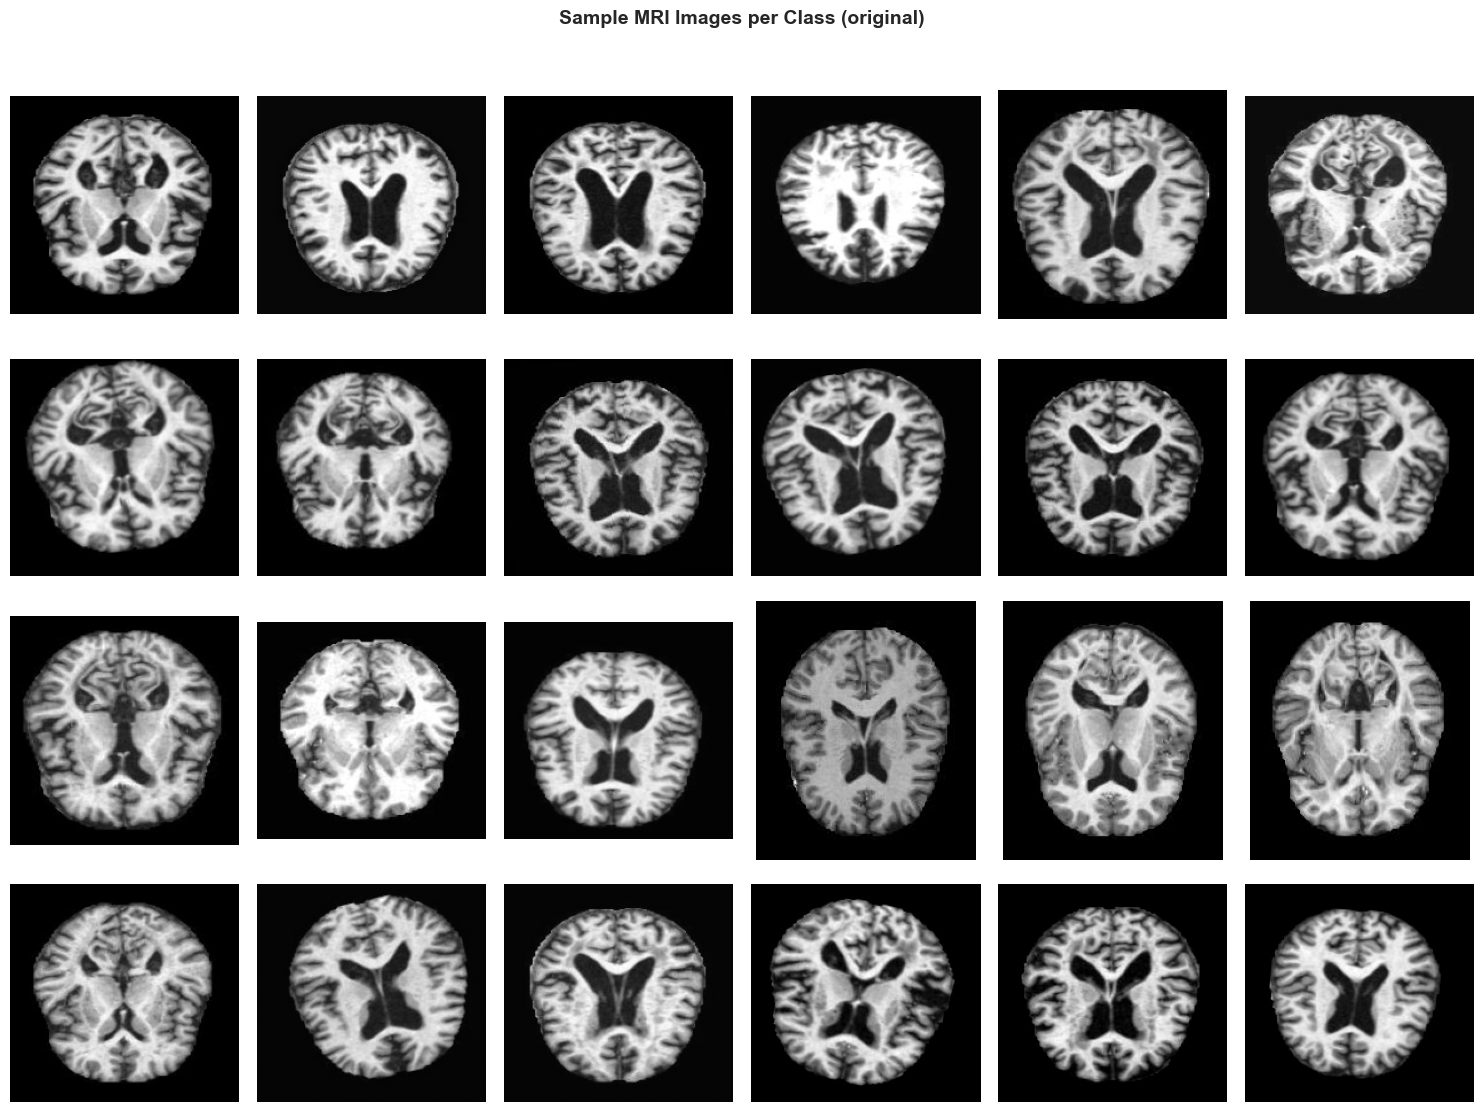

In [11]:
N_SAMPLES = 6 

fig, axes = plt.subplots(NUM_CLASSES, N_SAMPLES,
                         figsize=(N_SAMPLES * 2.5, NUM_CLASSES * 2.8))
fig.suptitle('Sample MRI Images per Class (original)', fontsize=14, fontweight='bold', y=1.01)

for row, (cls, label) in enumerate(zip(CLASS_NAMES, range(NUM_CLASSES))):
    cls_paths = [p for p, l in zip(all_paths, all_labels) if l == label]
    samples   = random.sample(cls_paths, N_SAMPLES)
    for col, path in enumerate(samples):
        img = Image.open(path).convert('L')
        axes[row][col].imshow(img, cmap='gray')
        axes[row][col].axis('off')
        if col == 0:
            axes[row][col].set_ylabel(SHORT_NAMES[row], fontsize=11,
                                      fontweight='bold', rotation=0,
                                      labelpad=60, va='center')

plt.tight_layout()
plt.show()

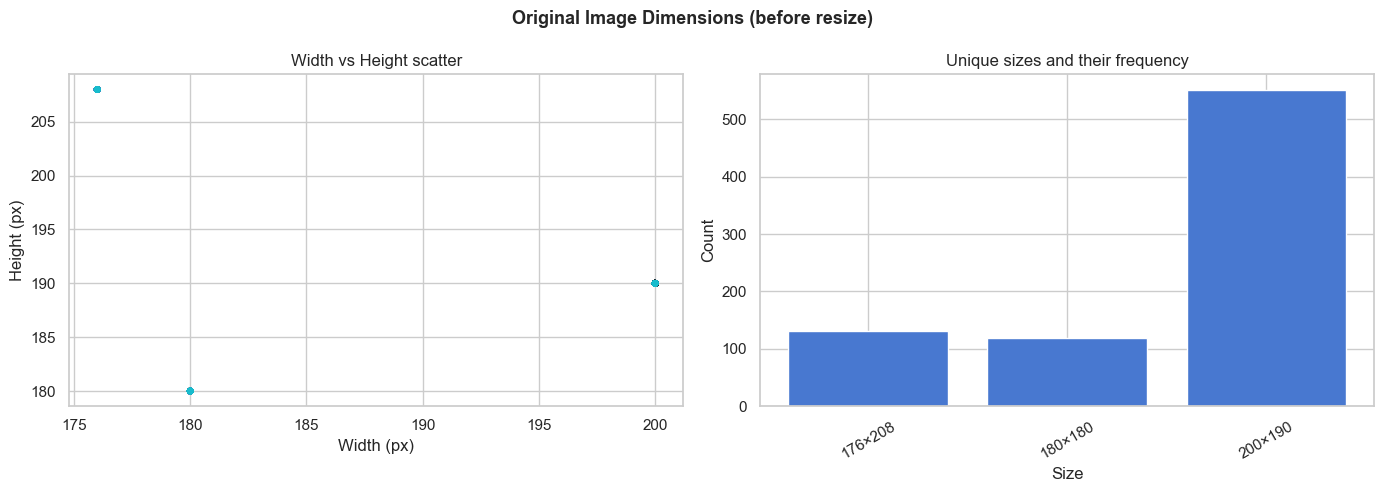

Unique sizes found: 3
 width  height  count
   176     208    131
   180     180    118
   200     190    551


In [14]:
N_SIZE_SAMPLES = 200
widths, heights, size_labels = [], [], []

for cls, label in zip(CLASS_NAMES, range(NUM_CLASSES)):
    cls_paths = [p for p, l in zip(all_paths, all_labels) if l == label]
    for path in random.sample(cls_paths, min(N_SIZE_SAMPLES, len(cls_paths))):
        w, h = Image.open(path).size
        widths.append(w)
        heights.append(h)
        size_labels.append(SHORT_NAMES[label])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Original Image Dimensions (before resize)', fontsize=13, fontweight='bold')

# Safe color mapping using SHORT_NAMES
label_to_id = {name: i for i, name in enumerate(SHORT_NAMES)}
color_ids = [label_to_id[lbl] for lbl in size_labels]

axes[0].scatter(
    widths, heights,
    c=color_ids,
    alpha=0.4, cmap='tab10', s=15
)
axes[0].set_xlabel('Width (px)'); axes[0].set_ylabel('Height (px)')
axes[0].set_title('Width vs Height scatter')

size_df = pd.DataFrame({'width': widths, 'height': heights, 'class': size_labels})
unique_sizes = size_df.groupby(['width', 'height']).size().reset_index(name='count')
axes[1].bar(
    range(len(unique_sizes)),
    unique_sizes['count'],
    tick_label=[f"{r.width}×{r.height}" for r in unique_sizes.itertuples()]
)
axes[1].set_title('Unique sizes and their frequency')
axes[1].set_xlabel('Size'); axes[1].set_ylabel('Count')
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()
print(f"Unique sizes found: {len(unique_sizes)}")
print(unique_sizes.to_string(index=False))

Train: 35200 | Val: 4400 | Test: 4400


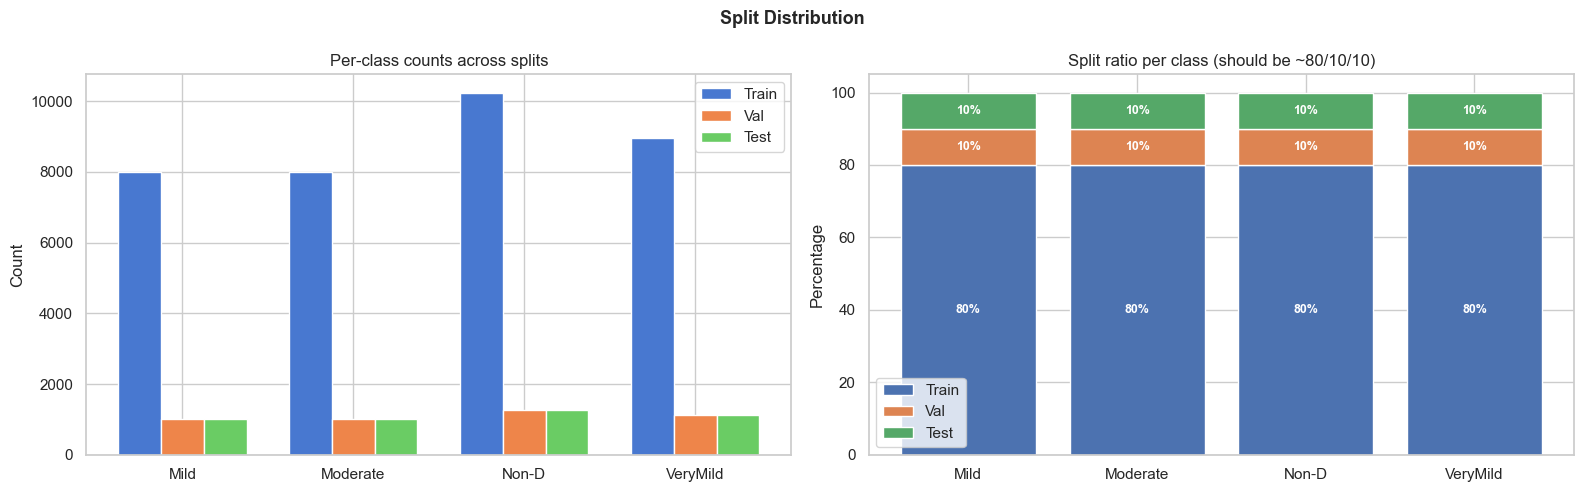

In [15]:
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    all_paths, all_labels,
    test_size=1 - TRAIN_RATIO,
    stratify=all_labels,
    random_state=SEED,
)
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels,
    test_size=0.5,
    stratify=temp_labels,
    random_state=SEED,
)

print(f"Train: {len(train_paths)} | Val: {len(val_paths)} | Test: {len(test_paths)}")

# ── Visualize split balance ────────────────────────────────────────────────
split_data = {}
for sname, lbls in [('Train', train_labels), ('Val', val_labels), ('Test', test_labels)]:
    c = Counter(lbls)
    split_data[sname] = [c[i] for i in range(NUM_CLASSES)]

x     = np.arange(NUM_CLASSES)
width = 0.25
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Split Distribution', fontsize=13, fontweight='bold')

# Grouped bar
for i, (sname, counts) in enumerate(split_data.items()):
    axes[0].bar(x + i*width, counts, width, label=sname)
axes[0].set_xticks(x + width)
axes[0].set_xticklabels(SHORT_NAMES)
axes[0].set_ylabel('Count')
axes[0].set_title('Per-class counts across splits')
axes[0].legend()

# Stacked % bar to check stratification is equal
totals = np.array([sum(split_data[s][i] for s in split_data) for i in range(NUM_CLASSES)])
bottom = np.zeros(NUM_CLASSES)
split_colors = ['#4C72B0', '#DD8452', '#55A868']
for (sname, counts), sc in zip(split_data.items(), split_colors):
    pct = np.array(counts) / totals * 100
    axes[1].bar(SHORT_NAMES, pct, bottom=bottom, label=sname, color=sc)
    for j, (p, b) in enumerate(zip(pct, bottom)):
        axes[1].text(j, b + p/2, f'{p:.0f}%', ha='center', va='center',
                     fontsize=9, color='white', fontweight='bold')
    bottom += pct
axes[1].set_ylabel('Percentage')
axes[1].set_title('Split ratio per class (should be ~80/10/10)')
axes[1].legend()

plt.tight_layout()
plt.show()

In [16]:
OUTPUT_DIR = Path(r"C:\Users\dell\.cursor\projects\AlexNet+svm\outputTensors")
if os.path.exists(OUTPUT_DIR):
    shutil.rmtree(OUTPUT_DIR)
os.makedirs(OUTPUT_DIR)

to_tensor = transforms.ToTensor()


def save_split(paths, labels, split_name):
    records = []
    for path, label in tqdm(zip(paths, labels), total=len(paths),
                            desc=f"Saving {split_name}"):
        cls_name = CLASS_NAMES[label]
        out_dir  = os.path.join(OUTPUT_DIR, split_name, cls_name)
        os.makedirs(out_dir, exist_ok=True)
        out_path = os.path.join(out_dir,
                    os.path.splitext(os.path.basename(path))[0] + ".pt")
        img    = Image.open(path).convert("L")
        img    = img.resize((IMAGE_SIZE, IMAGE_SIZE))
        tensor = to_tensor(img)
        tensor = (tensor * 255).byte()
        tensor = tensor.repeat(3, 1, 1)
        torch.save(tensor, out_path)
        records.append({'path': out_path, 'label': label,
                        'class': cls_name, 'split': split_name})
    return records


records  = save_split(train_paths, train_labels, "train")
records += save_split(val_paths,   val_labels,   "val")
records += save_split(test_paths,  test_labels,  "test")
print(f"\nTotal tensors saved: {len(records)}")

Saving test: 100%|██████████| 4400/4400 [01:01<00:00, 71.17it/s]


Total tensors saved: 44000


In [17]:
CSV_PATH = Path(r"C:\Users\dell\.cursor\projects\AlexNet+svm\split.csv")
df = pd.DataFrame(records)
df.to_csv(CSV_PATH, index=False)
print(f"Split manifest saved → {CSV_PATH}")
print(df.groupby(['split', 'class']).size().unstack().to_string())

Split manifest saved → C:\Users\dell\.cursor\projects\AlexNet+svm\split.csv
class  MildDemented  ModerateDemented  NonDemented  VeryMildDemented
split                                                               
test           1000              1000         1280              1120
train          8000              8000        10240              8960
val            1000              1000         1280              1120


In [19]:
META_PATH = Path(r"C:\Users\dell\.cursor\projects\AlexNet+svm\meta.json")
meta = {
    'class_names':   CLASS_NAMES,
    'num_classes':   NUM_CLASSES,
    'image_size':    IMAGE_SIZE,
    'use_ratio':     USE_RATIO,
    'train_ratio':   TRAIN_RATIO,
    'val_ratio':     VAL_RATIO,
    'imagenet_mean': IMAGENET_MEAN,
    'imagenet_std':  IMAGENET_STD,
    'tensor_dtype':  'uint8',
    'tensor_shape':  [3, IMAGE_SIZE, IMAGE_SIZE],
    'note':          'Convert: tensor.float() / 255.0 then Normalize(mean, std)',
    'seed':          SEED,
    'output_dir':    str(OUTPUT_DIR),
}
with open(META_PATH, 'w') as f:
    json.dump(meta, f, indent=2)
print(f"Metadata saved → {META_PATH}")

Metadata saved → C:\Users\dell\.cursor\projects\AlexNet+svm\meta.json


In [20]:
print("=== Tensor sanity check ===")
for split_name in ['train', 'val', 'test']:
    split_dir = os.path.join(OUTPUT_DIR, split_name)
    first_cls  = sorted(os.listdir(split_dir))[0]
    first_file = os.listdir(os.path.join(split_dir, first_cls))[0]
    t = torch.load(os.path.join(split_dir, first_cls, first_file), weights_only=True)
    print(f"  {split_name}: shape={tuple(t.shape)}  dtype={t.dtype}  "
          f"min={t.min().item()}  max={t.max().item()}")

=== Tensor sanity check ===
  train: shape=(3, 224, 224)  dtype=torch.uint8  min=0  max=219
  val: shape=(3, 224, 224)  dtype=torch.uint8  min=0  max=253
  test: shape=(3, 224, 224)  dtype=torch.uint8  min=0  max=171


In [21]:
summary = df.groupby(['split', 'class']).size().unstack(fill_value=0)
summary['TOTAL'] = summary.sum(axis=1)
print("\n=== Final split summary ===")
print(summary.to_string())
print(f"\nPreprocessing complete. All files in {OUTPUT_DIR}")


=== Final split summary ===
class  MildDemented  ModerateDemented  NonDemented  VeryMildDemented  TOTAL
split                                                                      
test           1000              1000         1280              1120   4400
train          8000              8000        10240              8960  35200
val            1000              1000         1280              1120   4400

Preprocessing complete. All files in C:\Users\dell\.cursor\projects\AlexNet+svm\outputTensors


EDA

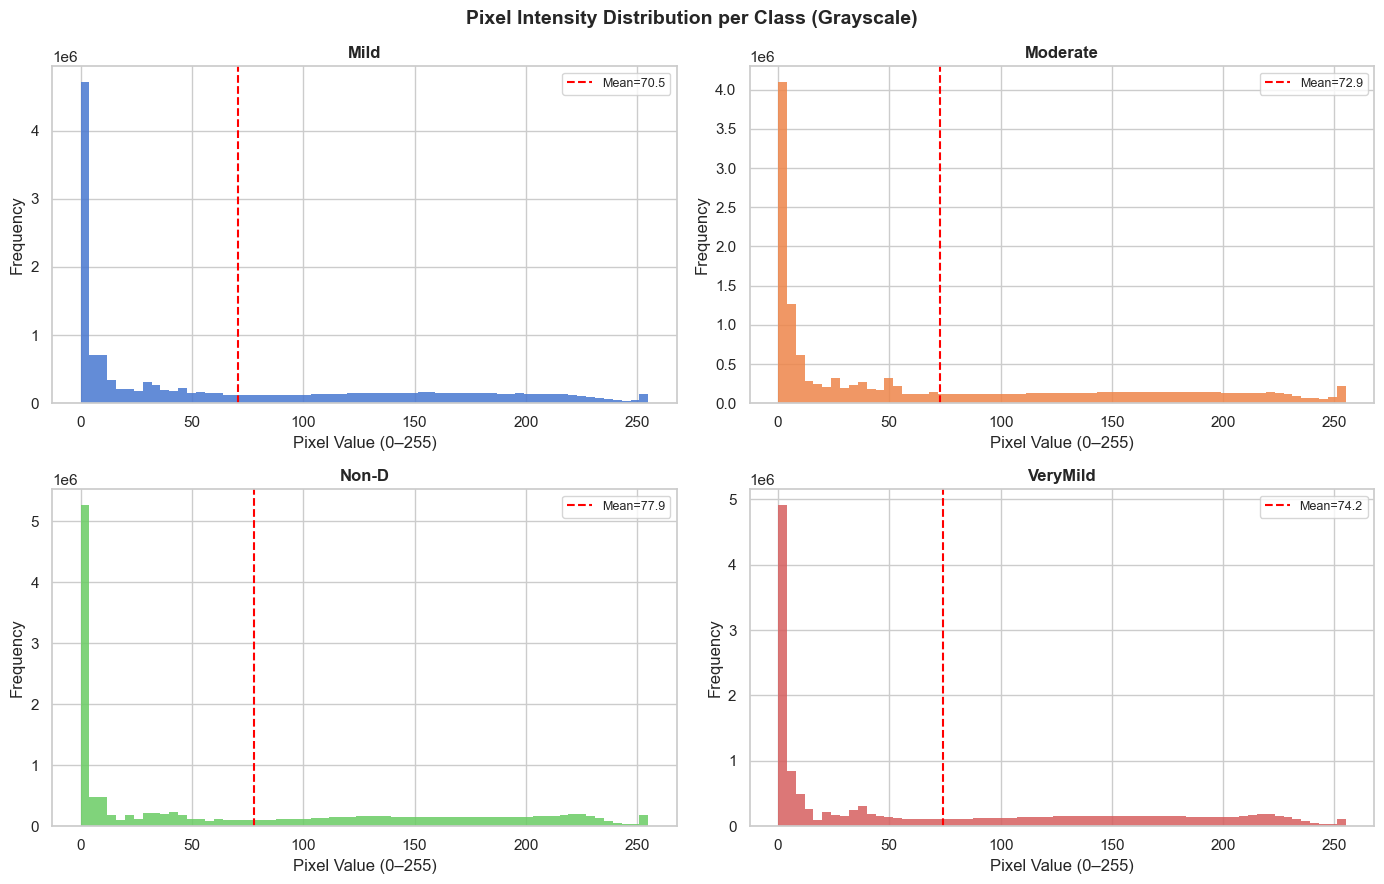

In [23]:
# ── 1. PIXEL INTENSITY DISTRIBUTION (per class) ─────────────────────────────
EDA_SAMPLES = 300
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()
fig.suptitle('Pixel Intensity Distribution per Class (Grayscale)', fontsize=14, fontweight='bold')

for idx, (cls, label) in enumerate(zip(CLASS_NAMES, range(NUM_CLASSES))):
    cls_paths = [p for p, l in zip(all_paths, all_labels) if l == label]
    sampled   = random.sample(cls_paths, min(EDA_SAMPLES, len(cls_paths)))
    all_pixels = []
    for path in sampled:
        img = np.array(Image.open(path).convert('L').resize((224, 224))).flatten()
        all_pixels.extend(img.tolist())
    all_pixels = np.array(all_pixels)
    axes[idx].hist(all_pixels, bins=64, color=sns.color_palette('muted')[idx],
                   alpha=0.85, edgecolor='none')
    axes[idx].axvline(all_pixels.mean(), color='red', linestyle='--', linewidth=1.5,
                      label=f'Mean={all_pixels.mean():.1f}')
    axes[idx].set_title(SHORT_NAMES[idx], fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Pixel Value (0–255)')
    axes[idx].set_ylabel('Frequency')
    axes[idx].legend(fontsize=9)

plt.tight_layout()
plt.show()

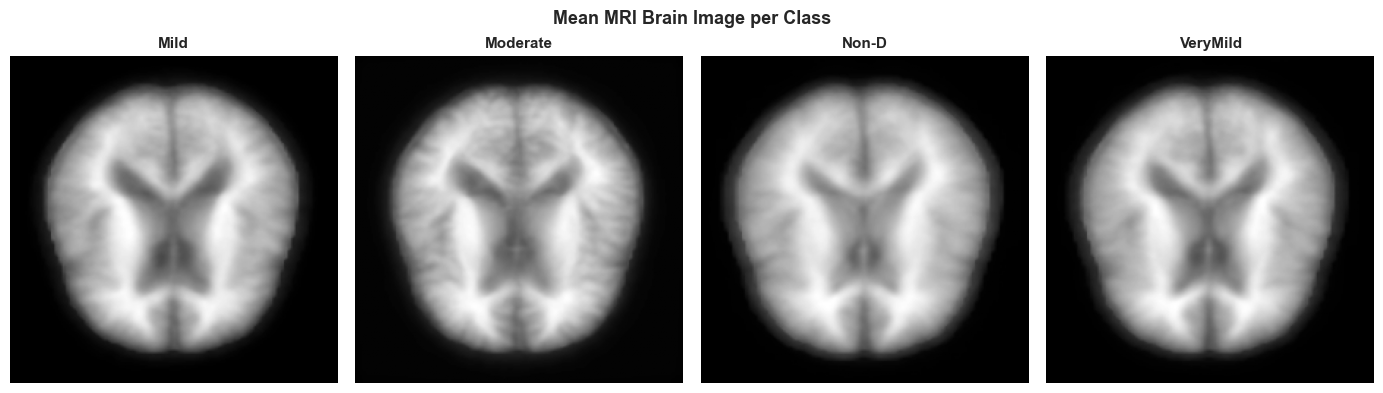

In [24]:
# ── 2. MEAN BRAIN IMAGE PER CLASS ────────────────────────────────────────────
fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(14, 4))
fig.suptitle('Mean MRI Brain Image per Class', fontsize=13, fontweight='bold')

mean_imgs = {}
for idx, (cls, label) in enumerate(zip(CLASS_NAMES, range(NUM_CLASSES))):
    cls_paths = [p for p, l in zip(all_paths, all_labels) if l == label]
    sampled   = random.sample(cls_paths, min(EDA_SAMPLES, len(cls_paths)))
    stack = np.stack([
        np.array(Image.open(p).convert('L').resize((224, 224)), dtype=np.float32)
        for p in sampled
    ])
    mean_img = stack.mean(axis=0).astype(np.uint8)
    mean_imgs[cls] = mean_img
    axes[idx].imshow(mean_img, cmap='gray')
    axes[idx].set_title(SHORT_NAMES[idx], fontsize=11, fontweight='bold')
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

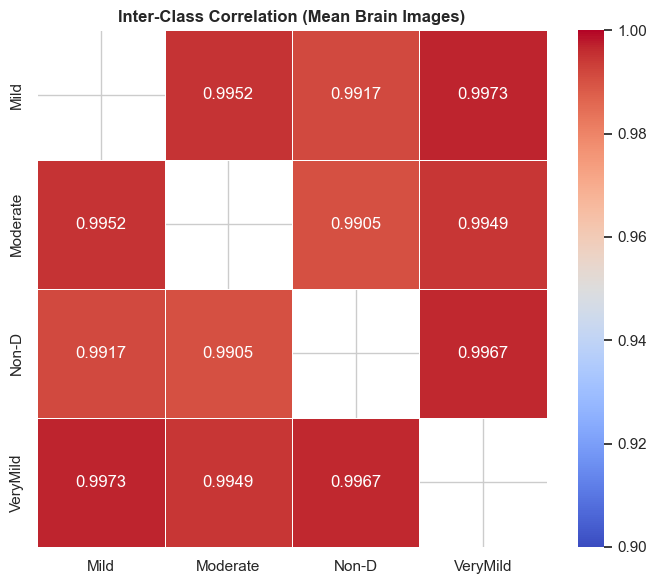

In [25]:
# ── 4. INTER-CLASS PIXEL CORRELATION HEATMAP ─────────────────────────────────
# Flatten mean images -> correlate class-level mean patterns
mean_flat = np.stack([mean_imgs[cls].flatten() for cls in CLASS_NAMES])
corr_matrix = np.corrcoef(mean_flat)

fig, ax = plt.subplots(figsize=(7, 6))
mask = np.zeros_like(corr_matrix, dtype=bool)
np.fill_diagonal(mask, True)
sns.heatmap(corr_matrix, annot=True, fmt='.4f', cmap='coolwarm',
            xticklabels=SHORT_NAMES, yticklabels=SHORT_NAMES,
            linewidths=0.5, ax=ax, vmin=0.9, vmax=1.0, mask=mask)
np.fill_diagonal(corr_matrix, np.nan)
sns.heatmap(corr_matrix, annot=True, fmt='.4f', cmap='coolwarm',
            xticklabels=SHORT_NAMES, yticklabels=SHORT_NAMES,
            linewidths=0.5, ax=ax, vmin=0.9, vmax=1.0,
            cbar=False, mask=~mask.__invert__().__invert__().__invert__().__invert__())
ax.set_title('Inter-Class Correlation (Mean Brain Images)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

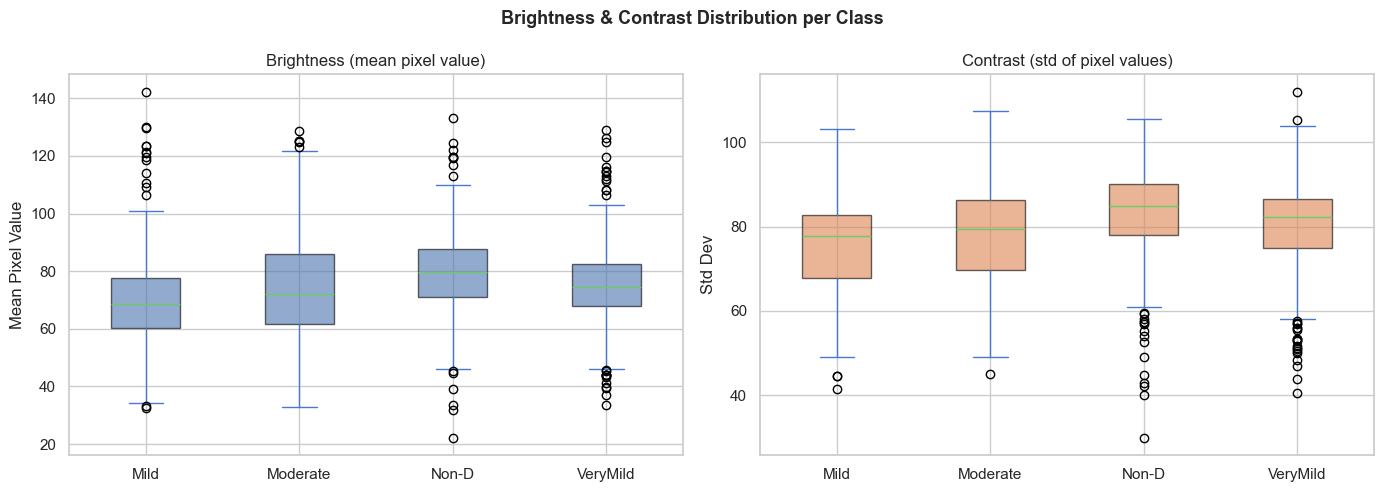


=== Brightness Stats ===
         Mild  Moderate   Non-D  VeryMild
count  300.00    300.00  300.00    300.00
mean    70.45     75.12   79.42     75.33
std     17.20     19.63   15.38     15.85
min     32.64     32.72   22.28     33.57
25%     60.30     61.81   70.89     67.76
50%     68.58     72.21   79.71     74.54
75%     77.70     86.14   87.57     82.50
max    142.31    128.63  133.18    129.10

=== Contrast Stats ===
         Mild  Moderate   Non-D  VeryMild
count  300.00    300.00  300.00    300.00
mean    75.62     77.90   82.37     79.66
std     10.98     11.81   11.38     11.68
min     41.58     44.98   30.00     40.54
25%     67.88     69.82   78.12     75.04
50%     77.88     79.40   84.79     82.29
75%     82.72     86.26   90.01     86.57
max    103.16    107.43  105.46    111.98


In [27]:
# ── BRIGHTNESS & CONTRAST STATS (box plots) ───────────────────────────────
brightness_data = {cls: [] for cls in CLASS_NAMES}
contrast_data   = {cls: [] for cls in CLASS_NAMES}

for idx, (cls, label) in enumerate(zip(CLASS_NAMES, range(NUM_CLASSES))):
    cls_paths = [p for p, l in zip(all_paths, all_labels) if l == label]
    sampled   = random.sample(cls_paths, min(EDA_SAMPLES, len(cls_paths)))
    for path in sampled:
        arr = np.array(Image.open(path).convert('L').resize((224, 224)), dtype=np.float32)
        brightness_data[cls].append(arr.mean())
        contrast_data[cls].append(arr.std())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Brightness & Contrast Distribution per Class', fontsize=13, fontweight='bold')

bright_df   = pd.DataFrame({k: pd.Series(v) for k, v in brightness_data.items()})
contrast_df = pd.DataFrame({k: pd.Series(v) for k, v in contrast_data.items()})

bright_df.columns   = SHORT_NAMES
contrast_df.columns = SHORT_NAMES

bright_df.plot(kind='box', ax=axes[0], patch_artist=True,
               boxprops=dict(facecolor='#4C72B0', alpha=0.6))
axes[0].set_title('Brightness (mean pixel value)'); axes[0].set_ylabel('Mean Pixel Value')

contrast_df.plot(kind='box', ax=axes[1], patch_artist=True,
                 boxprops=dict(facecolor='#DD8452', alpha=0.6))
axes[1].set_title('Contrast (std of pixel values)'); axes[1].set_ylabel('Std Dev')

plt.tight_layout()
plt.show()

# Print summary table
print("\n=== Brightness Stats ===")
print(bright_df.describe().round(2).to_string())
print("\n=== Contrast Stats ===")
print(contrast_df.describe().round(2).to_string())


AlexNet+SVM

In [29]:
class TensorDataset(Dataset):
    def __init__(self, split_name, output_dir, class_names, normalize_transform):
        self.samples   = []
        self.transform = normalize_transform
        split_dir = os.path.join(output_dir, split_name)
        for label, cls in enumerate(class_names):
            cls_dir = os.path.join(split_dir, cls)
            for fname in os.listdir(cls_dir):
                self.samples.append((os.path.join(cls_dir, fname), label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        tensor = torch.load(path, weights_only=True).float() / 255.0  # → [0,1]
        tensor = self.transform(tensor)
        return tensor, label

norm_transform = transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)

train_ds = TensorDataset('train', OUTPUT_DIR, CLASS_NAMES, norm_transform)
val_ds   = TensorDataset('val',   OUTPUT_DIR, CLASS_NAMES, norm_transform)
test_ds  = TensorDataset('test',  OUTPUT_DIR, CLASS_NAMES, norm_transform)

BATCH_SIZE = 128
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")

Train: 35200 | Val: 4400 | Test: 4400


In [30]:
# ── ALEXNET FEATURE EXTRACTOR ───────────────────────────────────────────────
alexnet = models.alexnet(weights=models.AlexNet_Weights.IMAGENET1K_V1)

alexnet.classifier = nn.Sequential(*list(alexnet.classifier.children())[:6])
alexnet = alexnet.to(DEVICE).eval()

def extract_features(loader, desc="Extracting"):
    feats, lbls = [], []
    with torch.no_grad():
        for imgs, labels in tqdm(loader, desc=desc):
            imgs = imgs.to(DEVICE)
            out  = alexnet(imgs).cpu().numpy()  
            feats.append(out)
            lbls.extend(labels.numpy())
    return np.vstack(feats), np.array(lbls)

print("Extracting train features...")
X_train, y_train = extract_features(train_loader, "Train")

print("Extracting val features...")
X_val,   y_val   = extract_features(val_loader,   "Val")

print("Extracting test features...")
X_test,  y_test  = extract_features(test_loader,  "Test")

print(f"\nFeature shapes → Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to C:\Users\dell/.cache\torch\hub\checkpoints\alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [08:36<00:00, 473kB/s]  


Extracting train features...


Train:   0%|          | 0/275 [00:00<?, ?it/s]C:\Users\dell\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
Train: 100%|██████████| 275/275 [09:24<00:00,  2.05s/it]


Extracting val features...


Val: 100%|██████████| 35/35 [01:08<00:00,  1.95s/it]


Extracting test features...


Test: 100%|██████████| 35/35 [01:09<00:00,  1.98s/it]


Feature shapes → Train: (35200, 4096) | Val: (4400, 4096) | Test: (4400, 4096)


In [31]:
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

In [32]:
svm = SVC(
    kernel='rbf',
    C=10,
    gamma='scale',
    probability=True, 
    random_state=SEED,
    cache_size=1000)
svm.fit(X_train, y_train)

val_acc = accuracy_score(y_val, svm.predict(X_val))
print(f"\nValidation Accuracy: {val_acc*100:.2f}%")



Validation Accuracy: 91.80%


In [33]:
y_pred = svm.predict(X_test)
y_prob = svm.predict_proba(X_test)   # shape: (N, 4)

test_accuracy = accuracy_score(y_test, y_pred)
print(f"  TEST ACCURACY:  {test_accuracy*100:.2f}%  (paper: 94.8%)")


  TEST ACCURACY:  91.48%  (paper: 94.8%)


In [35]:
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES, digits=4))

Classification Report:
                  precision    recall  f1-score   support

    MildDemented     0.9148    0.9130    0.9139      1000
ModerateDemented     0.9839    0.9750    0.9794      1000
     NonDemented     0.8841    0.9055    0.8946      1280
VeryMildDemented     0.8891    0.8732    0.8811      1120

        accuracy                         0.9148      4400
       macro avg     0.9180    0.9167    0.9173      4400
    weighted avg     0.9150    0.9148    0.9148      4400



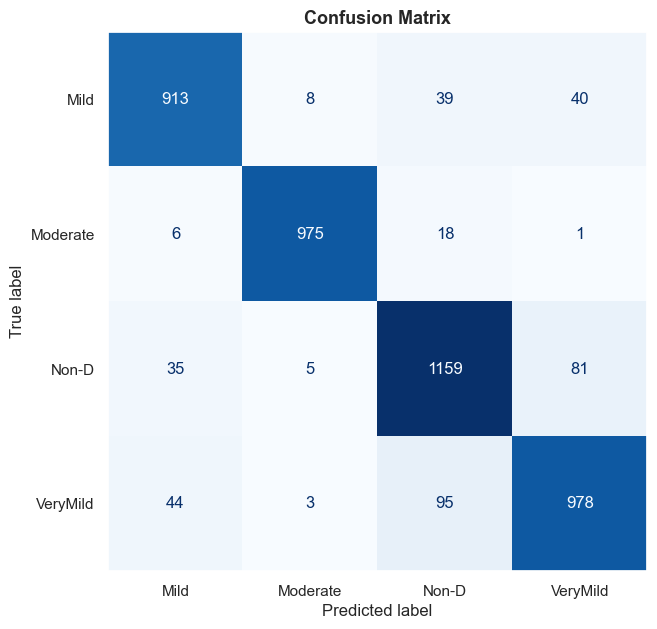

In [40]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 7))
disp = ConfusionMatrixDisplay(cm, display_labels=SHORT_NAMES)
disp.plot(ax=ax, cmap='Blues', colorbar=False, values_format='d')
ax.set_title('Confusion Matrix', fontsize=13, fontweight='bold')
ax.grid(False)
plt.show()

In [42]:
print(f"\n{'Class':<22} {'Sensitivity':>12} {'Specificity':>12} {'F1-Score':>10}")
print("-" * 60)

sens_list, spec_list = [], []
for i, cls in enumerate(CLASS_NAMES):
    tp = cm[i, i]
    fn = cm[i, :].sum() - tp
    fp = cm[:, i].sum() - tp
    tn = cm.sum() - tp - fn - fp

    sens = tp / (tp + fn + 1e-9)
    spec = tn / (tn + fp + 1e-9)

    f1 = f1_score(y_test, y_pred, labels=[i], average='macro')

    sens_list.append(sens)
    spec_list.append(spec)
    print(f"{cls:<22} {sens:>11.4f}  {spec:>11.4f}  {f1:>9.4f}")

print("-" * 60)
print(f"{'MACRO AVERAGE':<22} {np.mean(sens_list):>11.4f}  {np.mean(spec_list):>11.4f}")


Class                   Sensitivity  Specificity   F1-Score
------------------------------------------------------------
MildDemented                0.9130       0.9750     0.9139
ModerateDemented            0.9750       0.9953     0.9794
NonDemented                 0.9055       0.9513     0.8946
VeryMildDemented            0.8732       0.9628     0.8811
------------------------------------------------------------
MACRO AVERAGE               0.9167       0.9711


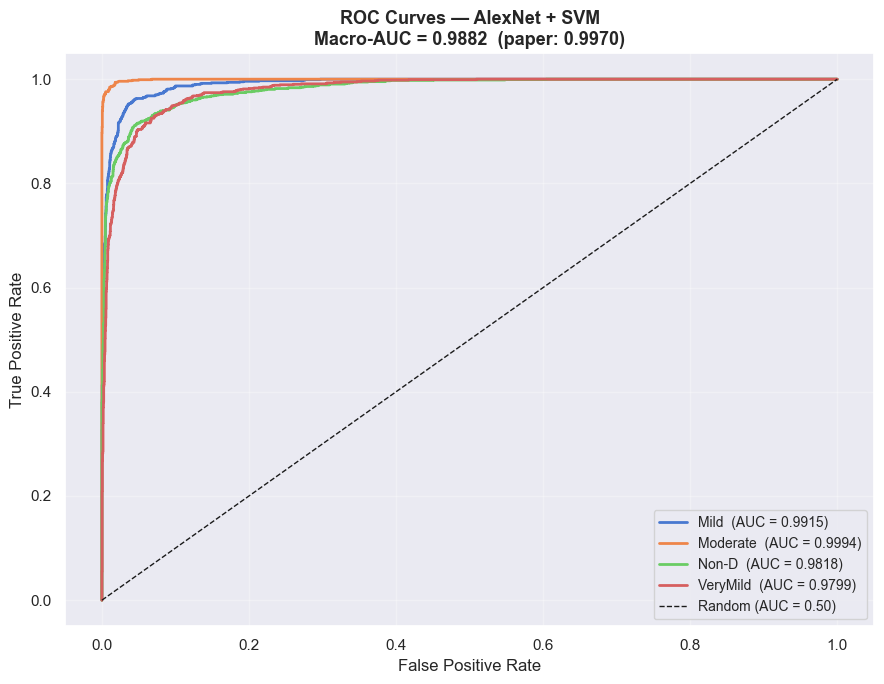


Macro-AUC: 0.9882


In [43]:
y_bin = label_binarize(y_test, classes=list(range(NUM_CLASSES)))

fig, ax = plt.subplots(figsize=(9, 7))
colors  = sns.color_palette('muted', NUM_CLASSES)
aucs    = []

for i, (cls, color) in enumerate(zip(CLASS_NAMES, colors)):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob[:, i])
    roc_auc     = auc(fpr, tpr)
    aucs.append(roc_auc)
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f'{SHORT_NAMES[i]}  (AUC = {roc_auc:.4f})')

macro_auc = np.mean(aucs)
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC = 0.50)')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title(f'ROC Curves — AlexNet + SVM\nMacro-AUC = {macro_auc:.4f}  (paper: 0.9970)',
             fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print(f"\nMacro-AUC: {macro_auc:.4f}")

In [44]:
summary_df = pd.DataFrame({
    'Class':       CLASS_NAMES,
    'Sensitivity': [f'{s:.4f}' for s in sens_list],
    'Specificity': [f'{s:.4f}' for s in spec_list],
    'AUC':         [f'{a:.4f}' for a in aucs],})

summary_df.loc[len(summary_df)] = [
    'MACRO AVG',
    f'{np.mean(sens_list):.4f}',
    f'{np.mean(spec_list):.4f}',
    f'{macro_auc:.4f}']

print("\n Final Evaluation Summary ")
print(f"Accuracy: {test_accuracy*100:.2f}%")
print()
print(summary_df.to_string(index=False))
print()
print("Reference (paper): Accuracy=94.8%, Sensitivity=93%, Specificity=97.75%, AUC=99.70%")


 Final Evaluation Summary 
Accuracy: 91.48%

           Class Sensitivity Specificity    AUC
    MildDemented      0.9130      0.9750 0.9915
ModerateDemented      0.9750      0.9953 0.9994
     NonDemented      0.9055      0.9513 0.9818
VeryMildDemented      0.8732      0.9628 0.9799
       MACRO AVG      0.9167      0.9711 0.9882

Reference (paper): Accuracy=94.8%, Sensitivity=93%, Specificity=97.75%, AUC=99.70%


In [45]:
import pickle, json
SAVE_DIR = Path(r"C:\Users\dell\.cursor\projects\AlexNet+svm\model")
SAVE_DIR.mkdir(exist_ok=True)

with open(SAVE_DIR / "svm.pkl", "wb") as f:
    pickle.dump(svm, f)

with open(SAVE_DIR / "scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

torch.save(alexnet.state_dict(), SAVE_DIR / "alexnet_extractor.pth")

params = {
    "svm_kernel":    "rbf",
    "svm_C":         10,
    "svm_gamma":     "scale",
    "n_components":  4096,
    "image_size":    224,
    "class_names":   CLASS_NAMES,
    "imagenet_mean": IMAGENET_MEAN,
    "imagenet_std":  IMAGENET_STD,
    "test_accuracy": float(test_accuracy * 100),
    "seed":          SEED,
}
with open(SAVE_DIR / "params.json", "w") as f:
    json.dump(params, f, indent=2)

print(" Model saved:")
for f in SAVE_DIR.iterdir():
    print(f" {f.name}")

 Model saved:
 alexnet_extractor.pth
 params.json
 scaler.pkl
 svm.pkl


In [46]:
SAVE_DIR = Path(r"C:\Users\dell\.cursor\projects\AlexNet+svm\model")

with open(SAVE_DIR / "svm.pkl", "rb") as f:
    svm = pickle.load(f)

with open(SAVE_DIR / "scaler.pkl", "rb") as f:
    scaler = pickle.load(f)

with open(SAVE_DIR / "params.json") as f:
    params = json.load(f)

print("Model loaded successfully")
print(json.dumps(params, indent=2))

Model loaded successfully
{
  "svm_kernel": "rbf",
  "svm_C": 10,
  "svm_gamma": "scale",
  "n_components": 4096,
  "image_size": 224,
  "class_names": [
    "MildDemented",
    "ModerateDemented",
    "NonDemented",
    "VeryMildDemented"
  ],
  "imagenet_mean": [
    0.485,
    0.456,
    0.406
  ],
  "imagenet_std": [
    0.229,
    0.224,
    0.225
  ],
  "test_accuracy": 91.47727272727273,
  "seed": 42
}


#XAI Models 

Grad-Cam

In [48]:
!pip install grad-cam -q
!pip install lime -q
!pip install shap -q
!pip install captum -q

In [49]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from torchvision import models
import torch, numpy as np
from PIL import Image
import matplotlib.pyplot as plt

alexnet_full = models.alexnet(weights=models.AlexNet_Weights.IMAGENET1K_V1).to(DEVICE).eval()

target_layer = [alexnet_full.features[10]]

cam = GradCAM(model=alexnet_full, target_layers=target_layer)

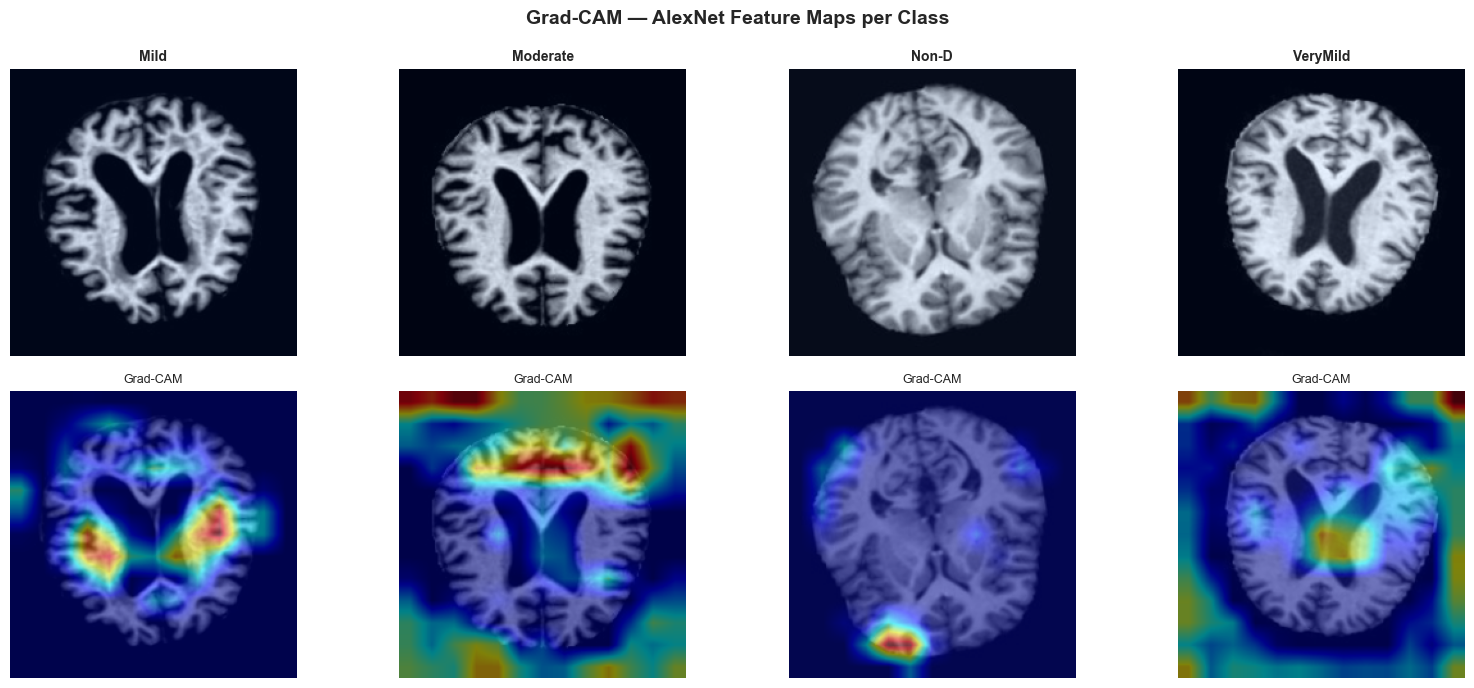

In [50]:
fig, axes = plt.subplots(2, len(CLASS_NAMES), figsize=(16, 7))
fig.suptitle("Grad-CAM — AlexNet Feature Maps per Class", fontsize=14, fontweight='bold')

for idx, (cls, label) in enumerate(zip(CLASS_NAMES, range(len(CLASS_NAMES)))):
    sample_idx = np.where(y_test == label)[0][0]
    tensor, _ = test_ds[sample_idx]
    input_tensor = tensor.unsqueeze(0).to(DEVICE)

    img_np = tensor.permute(1, 2, 0).numpy()
    img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min())

    targets = [ClassifierOutputTarget(label)]
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]
    cam_image = show_cam_on_image(img_np.astype(np.float32), grayscale_cam, use_rgb=True)

    axes[0][idx].imshow(img_np, cmap='gray')
    axes[0][idx].set_title(SHORT_NAMES[idx], fontsize=10, fontweight='bold')
    axes[0][idx].axis('off')

    axes[1][idx].imshow(cam_image)
    axes[1][idx].set_title('Grad-CAM', fontsize=9)
    axes[1][idx].axis('off')

plt.tight_layout()
plt.show()

Lime

In [51]:
from lime import lime_image
from skimage.segmentation import mark_boundaries

explainer = lime_image.LimeImageExplainer()

def pipeline_predict(images):
    tensors = []
    norm = transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
    for img in images:
        t = torch.tensor(img).permute(2,0,1).float()
        t = norm(t)
        tensors.append(t)
    batch = torch.stack(tensors).to(DEVICE)
    with torch.no_grad():
        feats = alexnet(batch).cpu().numpy()
    feats_sc = scaler.transform(feats)
    return svm.predict_proba(feats_sc)

C:\Users\dell\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 500/500 [00:45<00:00, 10.98it/s]


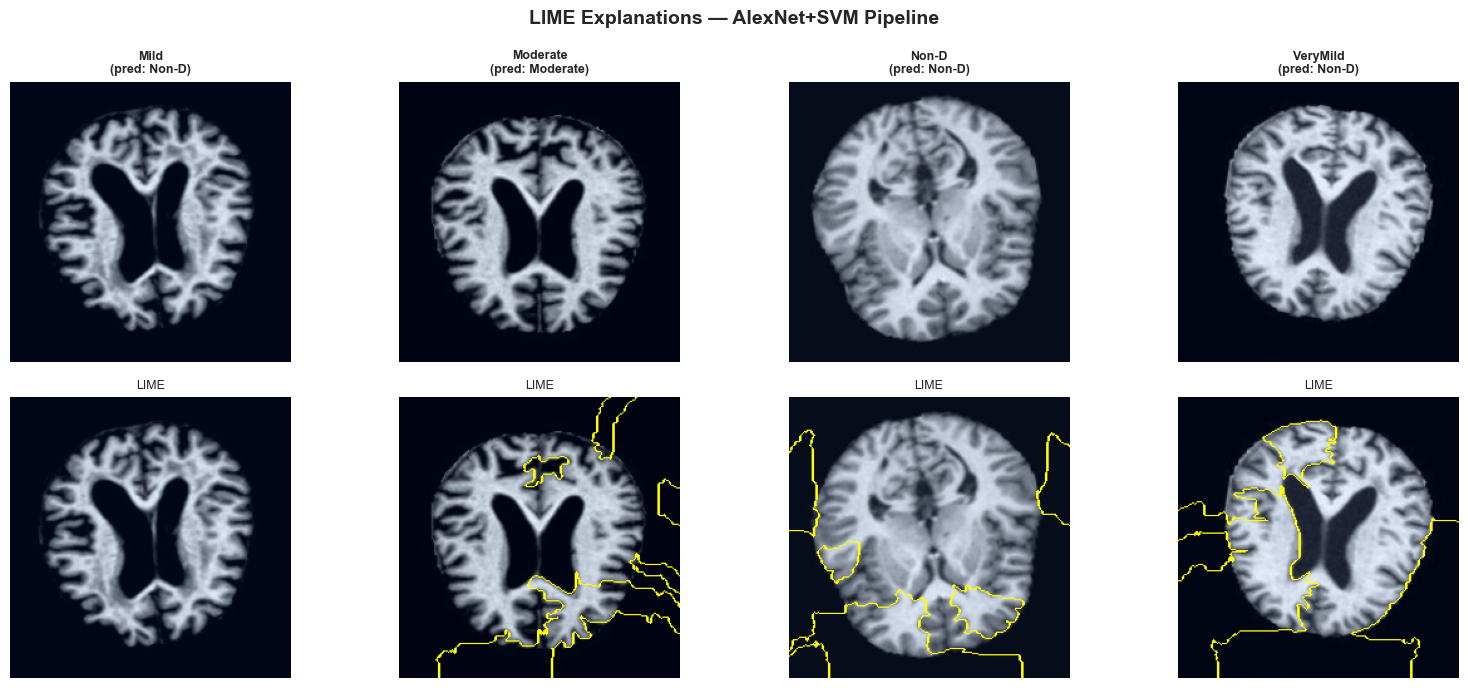

In [ ]:
fig, axes = plt.subplots(2, len(CLASS_NAMES), figsize=(16, 7))
fig.suptitle("LIME Explanations — AlexNet+SVM Pipeline", fontsize=14, fontweight='bold')

for idx, label in enumerate(range(len(CLASS_NAMES))):
    sample_idx = np.where(y_test == label)[0][0]
    tensor, _  = test_ds[sample_idx]

    img_np = tensor.permute(1,2,0).numpy()
    img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min())

    explanation = explainer.explain_instance(
        img_np.astype(np.double),
        pipeline_predict,
        top_labels=len(CLASS_NAMES),   
        hide_color=0,
        num_samples=500
    )

    top_label = explanation.top_labels[0]  

    temp, mask = explanation.get_image_and_mask(
        top_label, positive_only=True, num_features=8, hide_rest=False
    )

    axes[0][idx].imshow(img_np, cmap='gray')
    axes[0][idx].set_title(
        f"{SHORT_NAMES[idx]}\n(pred: {SHORT_NAMES[top_label]})",
        fontsize=9, fontweight='bold')
    axes[0][idx].axis('off')

    axes[1][idx].imshow(mark_boundaries(temp, mask))
    axes[1][idx].set_title('LIME', fontsize=9)
    axes[1][idx].axis('off')

plt.tight_layout()
plt.show()

Shap

In [ ]:
import shap
background_idx = np.random.choice(len(X_train), size=100, replace=False)
background = X_train[background_idx]

test_samples, test_labels_xai = [], []
for label in range(len(CLASS_NAMES)):
    idx = np.where(y_test == label)[0][0]
    test_samples.append(X_test[idx])
    test_labels_xai.append(label)
test_samples = np.array(test_samples)

explainer_shap = shap.KernelExplainer(
    svm.predict_proba,  
    background,
    link="identity")

print("Computing SHAP values")
shap_values = explainer_shap.shap_values(test_samples, nsamples=200)
print("Done")

Computing SHAP values


100%|██████████| 4/4 [1:45:33<00:00, 1583.32s/it]

Done


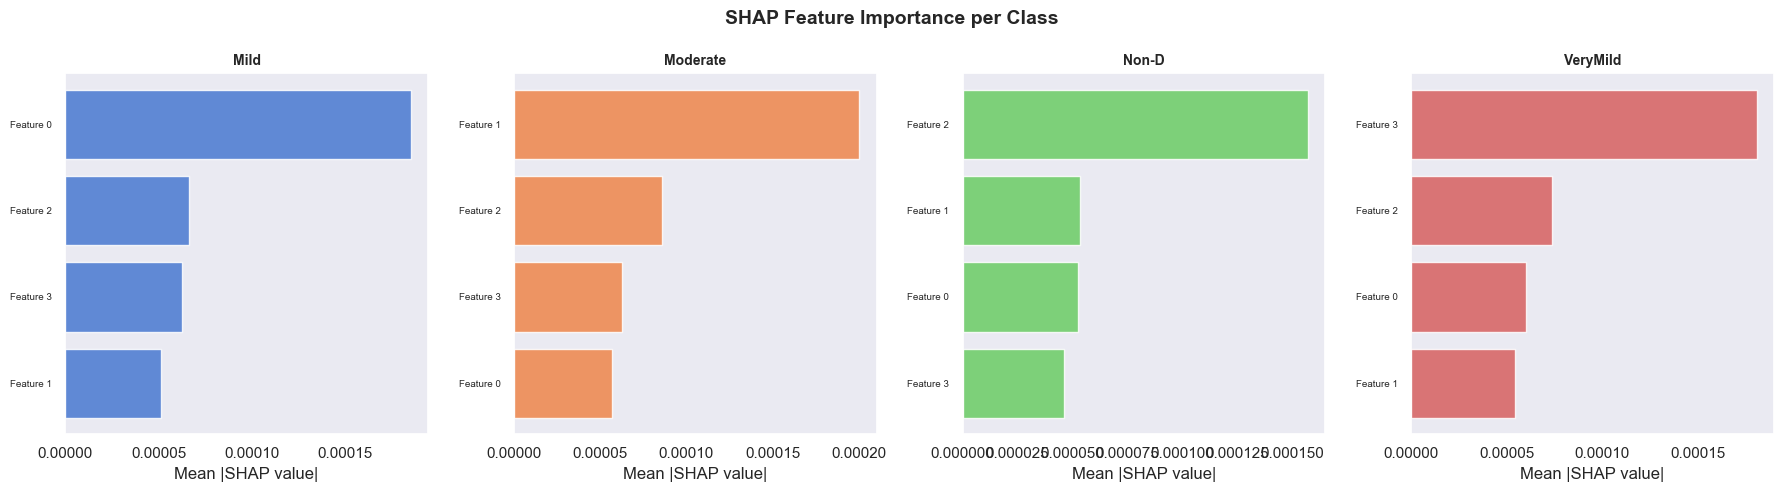

In [ ]:
fig, axes = plt.subplots(1, len(CLASS_NAMES), figsize=(18, 5))
fig.suptitle("SHAP Feature Importance per Class", fontsize=14, fontweight='bold')

for i, cls in enumerate(CLASS_NAMES):
    vals      = np.abs(shap_values[i])      # (4, 4096)
    mean_vals = vals.mean(axis=0)           # (4096,)

    # Dynamically set n based on available features
    n = min(15, len(mean_vals))
    top_idx  = np.argsort(mean_vals)[-n:][::-1]
    top_vals = mean_vals[top_idx]           

    axes[i].barh(range(n), top_vals[::-1],
                 color=sns.color_palette('muted')[i], alpha=0.85)
    axes[i].set_yticks(range(n))
    axes[i].set_yticklabels([f'Feature {j}' for j in top_idx[::-1]], fontsize=7)
    axes[i].set_title(SHORT_NAMES[i], fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Mean |SHAP value|')
    axes[i].grid(False)

plt.tight_layout()
plt.show()

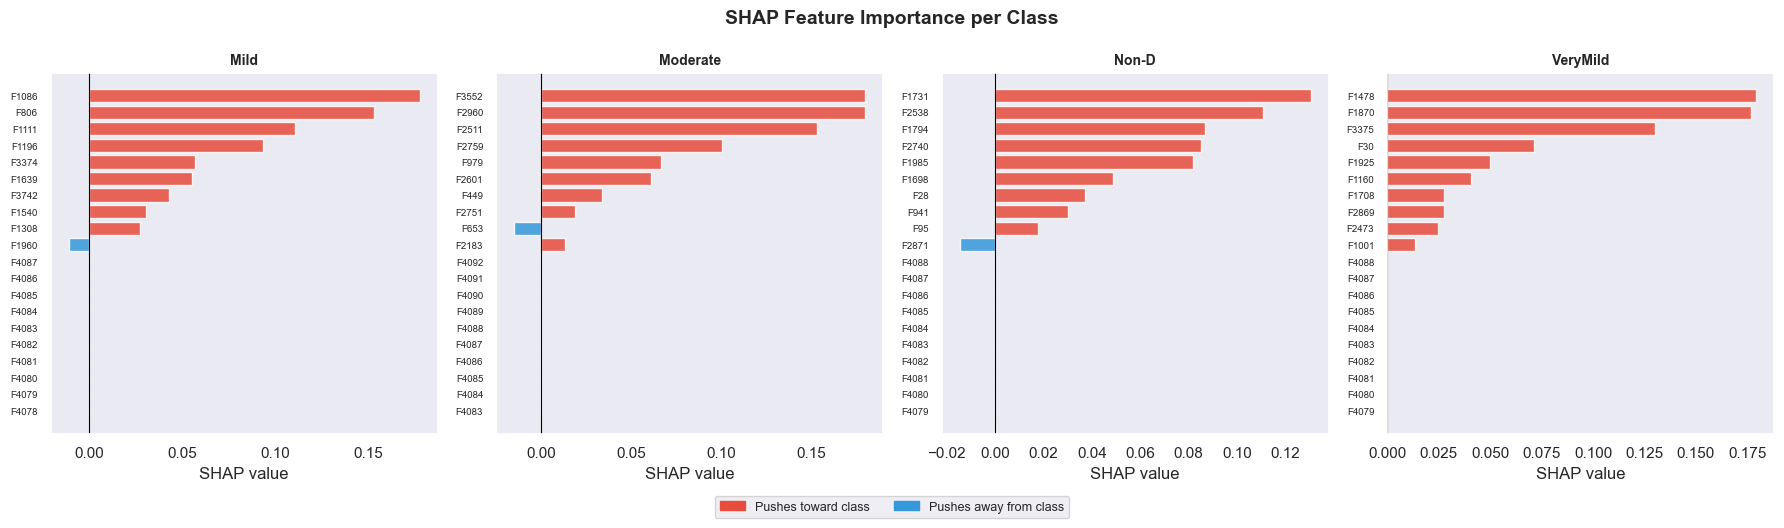

In [ ]:
fig, axes = plt.subplots(1, len(CLASS_NAMES), figsize=(18, 5))
fig.suptitle("SHAP Feature Importance per Class",
             fontsize=14, fontweight='bold')

for i, label in enumerate(range(len(CLASS_NAMES))):
    sv = shap_values[i][:, i]     

    n = 20
    top_idx  = np.argsort(np.abs(sv))[-n:][::-1]   
    top_sv   = sv[top_idx]                         
    colors   = ['#e74c3c' if v > 0 else '#3498db' for v in top_sv]

    axes[i].barh(range(n), top_sv[::-1], color=colors[::-1], alpha=0.85)
    axes[i].set_yticks(range(n))
    axes[i].set_yticklabels([f'F{j}' for j in top_idx[::-1]], fontsize=7)
    axes[i].set_title(SHORT_NAMES[i], fontsize=10, fontweight='bold')
    axes[i].set_xlabel('SHAP value')
    axes[i].axvline(0, color='black', linewidth=0.8)
    axes[i].grid(False)

from matplotlib.patches import Patch
legend = [Patch(color='#e74c3c', label='Pushes toward class'),
          Patch(color='#3498db', label='Pushes away from class')]
fig.legend(handles=legend, loc='lower center', ncol=2,
           fontsize=9, bbox_to_anchor=(0.5, -0.05))

plt.tight_layout()
plt.show()


Integrated Gradients

In [68]:
from captum.attr import IntegratedGradients
from captum.attr import visualization as viz

ig = IntegratedGradients(alexnet_full)

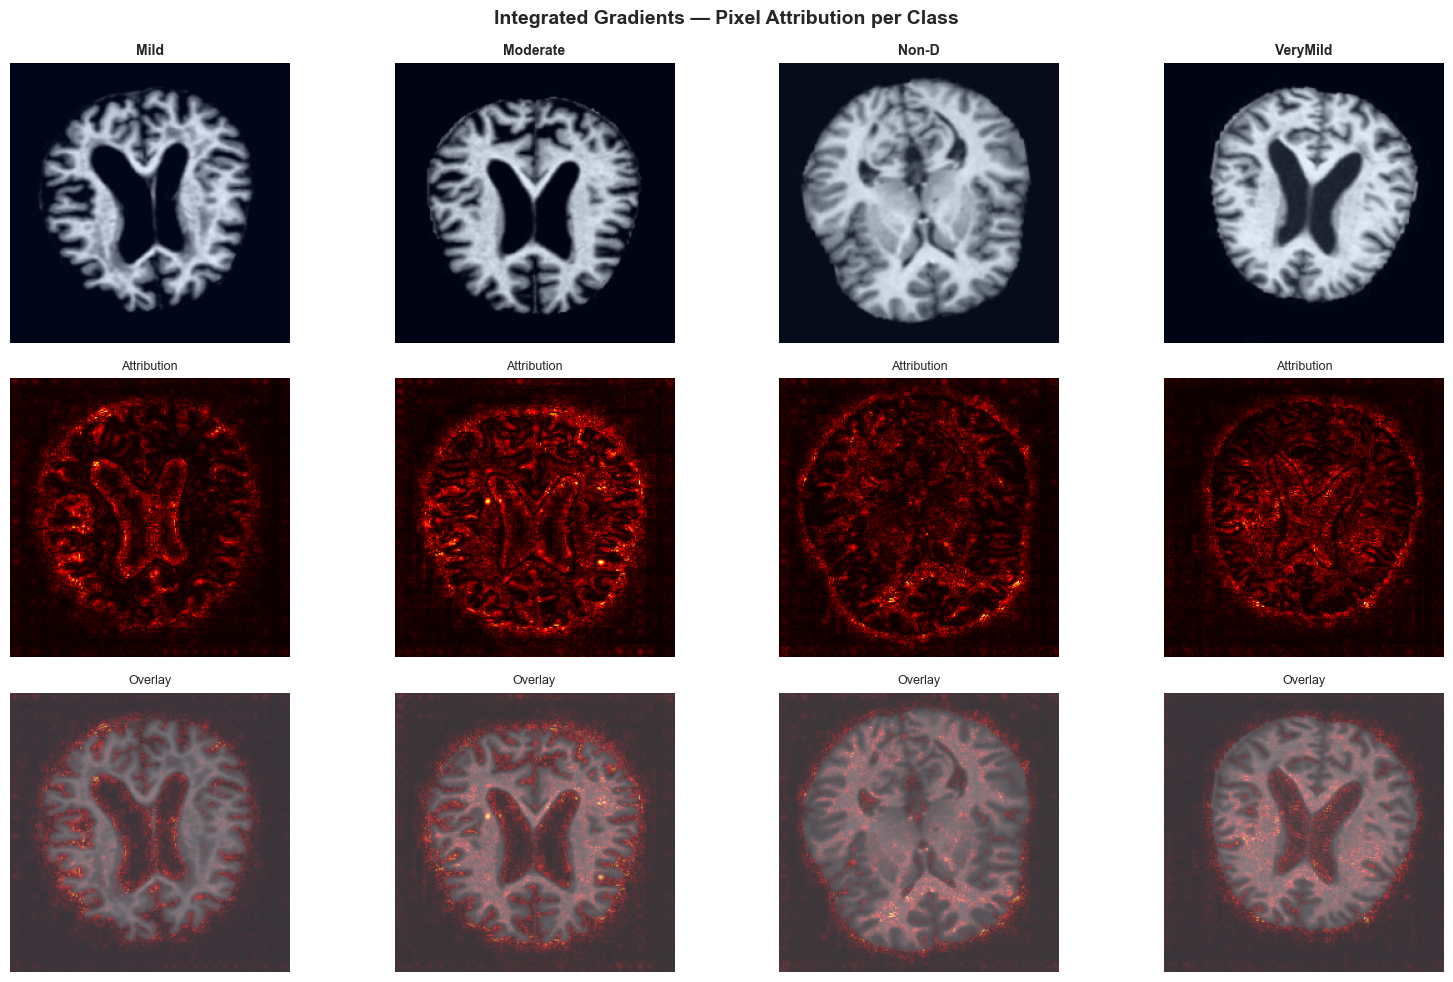

In [69]:
fig, axes = plt.subplots(3, len(CLASS_NAMES), figsize=(16, 10))
fig.suptitle("Integrated Gradients — Pixel Attribution per Class",fontsize=14, fontweight='bold')

for idx, label in enumerate(range(len(CLASS_NAMES))):
    sample_idx  = np.where(y_test == label)[0][0]
    tensor, _   = test_ds[sample_idx]
    input_tensor = tensor.unsqueeze(0).to(DEVICE).requires_grad_(True)
    baseline = torch.zeros_like(input_tensor)
    attributions = ig.attribute(
        input_tensor,
        baseline,
        target=label,
        n_steps=50,
        return_convergence_delta=False)

    attr_np = attributions.squeeze().permute(1,2,0).detach().cpu().numpy()
    attr_np = np.mean(np.abs(attr_np), axis=2)
    attr_np = (attr_np - attr_np.min()) / (attr_np.max() - attr_np.min() + 1e-8)

    img_np  = tensor.permute(1,2,0).numpy()
    img_np  = (img_np - img_np.min()) / (img_np.max() - img_np.min())

    axes[0][idx].imshow(img_np, cmap='gray')
    axes[0][idx].set_title(SHORT_NAMES[idx], fontsize=10, fontweight='bold')
    axes[0][idx].axis('off')

    axes[1][idx].imshow(attr_np, cmap='hot')
    axes[1][idx].set_title('Attribution', fontsize=9)
    axes[1][idx].axis('off')

    axes[2][idx].imshow(img_np, cmap='gray', alpha=0.6)
    axes[2][idx].imshow(attr_np, cmap='hot', alpha=0.5)
    axes[2][idx].set_title('Overlay', fontsize=9)
    axes[2][idx].axis('off')

plt.tight_layout()
plt.show()